In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from XStream_utils import plot_corner, h_mean_quantile

import scienceplots
plt.style.use('science')
import corner
from scipy.interpolate import griddata

import interpax

In [2]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [3]:
!nvidia-smi

Wed Jun  3 15:36:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:05:00.0 Off |                    0 |
| N/A   39C    P0             64W /  350W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

In [5]:
# Define the base name once
base_name = 'UDG_KL_w17c5_kval'
base_name2 = 'UDG_KL_w17c2_kval'


# Use the variable in file paths
dict_load = np.load(f'{base_name}.npy', allow_pickle=True).item()
constrained_values_truth = np.load(f'constrained_values_truth_{base_name}.npy', allow_pickle=True).item()


dict_load2 = np.load(f'{base_name2}.npy', allow_pickle=True).item()
constrained_values_truth2 = np.load(f'constrained_values_truth_{base_name2}.npy', allow_pickle=True).item()


In [6]:

points_c5 = dict_load['points']
log_w_c5 = dict_load['log_w']
log_l_c5 = dict_load['log_l']



points_c2 = dict_load2['points']
log_w_c2 = dict_load2['log_w']
log_l_c2 = dict_load2['log_l']



In [7]:
true_params = np.array([constrained_values_truth['y_prog'], 
                        constrained_values_truth['speed'], 
                        constrained_values_truth['vel_theta'],
                        constrained_values_truth['vel_phi'],
                        constrained_values_truth['log10_M_prog'],
                        constrained_values_truth['log10_m_halo'],
                        constrained_values_truth['r_s'],
                         constrained_values_truth['gamma'],
                         constrained_values_truth['beta'],
                         constrained_values_truth['t_age']
                        ])

prior_keys =   ['y_prog',
                '$v$',
                'theta',
                'phi',
                'log10_M_prog',
                'log10_m_halo',
                'r_s',
                'gamma',
                'beta',
                't_age']

In [8]:
def Lambda_func(Delta_sigma, N):
    sigma = Delta_sigma + 1
    return N*( -np.log(sigma) -  0.5*((1./sigma**2)) + 0.5  )

Delta_sigma_arr = np.linspace(0,10,100)
def inverse_Lambda_func(Lambda_value,N):
    base_Lambda = Lambda_func(Delta_sigma_arr,N)
    argsort = np.argsort(base_Lambda)
    Lambda_out = base_Lambda[argsort]
    Delta_sigma_arr_resort = Delta_sigma_arr[argsort]
    func = interpax.Interpolator1D(Lambda_out, Delta_sigma_arr_resort, method='cubic')
    return func(Lambda_value)

def P_of_DeltaSig(Delta_sigma):
    return (1./np.sqrt(2*np.pi) )*np.exp(-0.5*Delta_sigma**2)
    

## Rememeber, our log_l is negative KL div
Q_model_c5= -log_l_c5
Q_best_c5 = Q_model_c5[np.argmax(log_l_c5)]
N_c5 = 94#len(dat_outer)
Lambda_measured_c5 = N_c5*(Q_best_c5- Q_model_c5)


DeltaSig_measured_c5 = inverse_Lambda_func(Lambda_measured_c5,N_c5)
prob_values_of_samples_c5 = P_of_DeltaSig(DeltaSig_measured_c5)
good_bool_c5 =  ~np.isnan(prob_values_of_samples_c5)
prob_values_of_samples_c5 = prob_values_of_samples_c5[good_bool_c5]/prob_values_of_samples_c5[good_bool_c5].sum()
points_good_c5 = points_c5[good_bool_c5]
points_arange_c5 = np.arange(len(points_good_c5))

In [9]:
#for new contours in other notebook 
chains_c5 = {
    'points_good': points_good_c5,
    'prob_values_of_samples': prob_values_of_samples_c5
}

np.save('chains_c5.npy', chains_c5)

In [10]:


## Rememeber, our log_l is negative KL div
Q_model_c2= -log_l_c2
Q_best_c2 = Q_model_c2[np.argmax(log_l_c2)]
N_c2 = 94#len(dat_outer)
Lambda_measured_c2 = N_c2*(Q_best_c2- Q_model_c2)


DeltaSig_measured_c2 = inverse_Lambda_func(Lambda_measured_c2,N_c2)
prob_values_of_samples_c2 = P_of_DeltaSig(DeltaSig_measured_c2)
good_bool_c2 =  ~np.isnan(prob_values_of_samples_c2)
prob_values_of_samples_c2 = prob_values_of_samples_c2[good_bool_c2]/prob_values_of_samples_c2[good_bool_c2].sum()
points_good_c2 = points_c2[good_bool_c2]
points_arange_c2 = np.arange(len(points_good_c2))

In [11]:
chains_c2 = {
    'points_good': points_good_c2,
    'prob_values_of_samples': prob_values_of_samples_c2
}

np.save('chains_c2.npy', chains_c2)

In [12]:
# Parameter indices
GAMMA_IDX, LOGprog10M_IDX, LOG10M_IDX  = 5, 4, 7 

# param_labels = [
#     r'$\log_{10}(M_{\rm halo}/{\rm M}_\odot)$',
#     r'$\log_{10}(M_{\rm prog}/{\rm M}_\odot)$',
#     r'$\gamma$',
 
# ]

param_labels = [
    r'logM$_{\rm p}/$M$_\odot$',
    r'logM$_{\rm h}/$M$_\odot$',
    r'$\gamma$',
]

true_params = [1,11.5,6]
param_cols   = [GAMMA_IDX, LOGprog10M_IDX, LOG10M_IDX ]

pts_c5 = chains_c5['points_good'][:, param_cols]
w_c5   = chains_c5['prob_values_of_samples']

pts_c2 = chains_c2['points_good'][:, param_cols]
w_c2   = chains_c2['prob_values_of_samples']


In [13]:
# Parameter indices
#GAMMA_IDX, LOGprog10M_IDX, LOG10M_IDX  = 5, 4, 7 

# param_labels_all = [r'$y_{\rm prog}$', 
#                     r'$v$', 
#                     r'$\theta$', 
#                      r'$\phi$', 
#                     r'$\log_{10}\!\left( M_{\rm prog} / M_\odot \right)$',
#                     r'$\log_{10}\!\left( M_{\rm halo} / M_\odot \right)$',
#                     r'$r_s$',
#                     r'$\gamma$',
#                     r'$\beta$',
#                     r'$t_{\rm age}$']

param_labels_all = [r'$y_{\rm prog}$', 
                    r'$v$', 
                    r'$\theta$', 
                     r'$\phi$', 
                    r'logM$_{\rm p}/$M$_\odot$',
                    r'logM$_{\rm h}/$M$_\odot$',
                    r'$r_s$',
                    r'$\gamma$',
                    r'$\beta$',
                    r'$t_{\rm age}$']

# param_labels_all = [r'$y_{\rm prog}$', 
#                     r'$v$', 
#                     r'$\theta$', 
#                     r'$\phi$', 
#                     r'$\log_{10}( M_{\rm prog}$'+'\n'+r'$/ M_\odot )$',
#                     r'$\log_{10}( M_{\rm halo}$'+'\n'+r'$/ M_\odot )$',
#                     r'$r_s$',
#                     r'$\gamma$',
#                     r'$\beta$',
#                     r'$t_{\rm age}$']

true_params_all = [100,0,0,0,0,1,11.5,6,0,0]
#param_cols   = [GAMMA_IDX, LOGprog10M_IDX, LOG10M_IDX ]

pts_c5_all = chains_c5['points_good']
w_c5_all  = chains_c5['prob_values_of_samples']

pts_c2_all = chains_c2['points_good']
w_c2_all   = chains_c2['prob_values_of_samples']


In [14]:
np.random.seed(50430)
idx_c5 = np.random.choice(points_arange_c5,p=prob_values_of_samples_c5,size=5_000)
points_select_c5 = points_good_c5[idx_c5]


In [15]:
np.random.seed(50430)
idx_c2 = np.random.choice(points_arange_c2,p=prob_values_of_samples_c2,size=5_000)
points_select_c2 = points_good_c2[idx_c2]


In [16]:
# np.random.seed(50430)
# idx_c2 = np.random.choice(points_arange2,p=prob_values_of_samples2,size=5_000)
# points_select2 = points_good2[idx_c2]


In [17]:
best_idx_c5 = np.argmax(log_l_c5)  # Index of the highest log-likelihood
best_params_c5 = points_c5[best_idx_c5]


In [18]:
best_params_c5

array([1.61388587e-01, 7.29649506e-02, 1.16851419e+00, 6.70426752e-01,
       4.67902002e+00, 1.08446419e+01, 6.52258189e+00, 9.14223242e-01,
       2.40698347e+00, 1.34888071e+03])

In [19]:
best_fit_idx = np.argmax(prob_values_of_samples_c5)  # Index of the highest probability
best_params = points_good_c5[best_fit_idx]  # Get corresponding parameter values

print("Best-fit parameters:", best_params)

Best-fit parameters: [1.61388587e-01 7.29649506e-02 1.16851419e+00 6.70426752e-01
 4.67902002e+00 1.08446419e+01 6.52258189e+00 9.14223242e-01
 2.40698347e+00 1.34888071e+03]


In [20]:
# 

In [21]:
# best_idx = np.argmax(log_l)  # Index of the highest log-likelihood
# best_params = points[best_idx]

In [22]:
print(best_params)

[1.61388587e-01 7.29649506e-02 1.16851419e+00 6.70426752e-01
 4.67902002e+00 1.08446419e+01 6.52258189e+00 9.14223242e-01
 2.40698347e+00 1.34888071e+03]


In [23]:
true_params_new = true_params

In [24]:
## Instead of new random point each time

selected_point = np.array([-1.453049770915202,0.14849854495873663,1.1646965124123028,0.9010333683221128,  6.30102999566398,\
                         11.133813088679272,7.448468115059323,1.5019128456646849, 3.297736114240786, 600])



## Now also select within 1 sigma to visuazlie solutiobs

In [25]:
# # 1-sigma bounds from the weighted subsample
# lower_bounds_c5 = np.percentile(points_select_c5, 16, axis=0)
# upper_bounds_c5 = np.percentile(points_select_c5, 84, axis=0)

# # Joint 1-sigma mask across all 10 dimensions
# inside_1sigma_c5 = np.all(
#     (points_select_c5 >= lower_bounds_c5) & (points_select_c5 <= upper_bounds_c5),
#     axis=1
# )

# points_inside = points_select_c5[inside_1sigma_c5]
# print(f"Found {len(points_inside)} points within 1-sigma")

# np.random.seed(50430)
# random_indices = np.random.choice(len(points_inside), size=5, replace=False)
# selected_points_1sigma = points_inside[random_indices]

# print(f"\nSelected 5 random points (all 10 dimensions):")
# for n, pt in enumerate(selected_points_1sigma):
#     print(f"\n  Point {n+1}:")
#     for k, val in enumerate(pt):
#         print(f"    Index {k}: {val:.4f}")
#     print(f"    Progenitor mass (index 4): {10**pt[4]:.3e} Msun")

In [26]:
####DID below to get low mass bound for good fit######


# prog_mass_index = 4
# target_mass = np.log10(1.65e5)  # ≈ 5.217
# mass_tol = 0.01  # in log space, adjust if needed

# # 1-sigma bounds from the weighted subsample
# lower_bounds_c5 = np.percentile(points_select_c5, 16, axis=0)
# upper_bounds_c5 = np.percentile(points_select_c5, 84, axis=0)

# # Joint 1-sigma mask across all 10 dimensions
# inside_1sigma_c5 = np.all(
#     (points_select_c5 >= lower_bounds_c5) & (points_select_c5 <= upper_bounds_c5),
#     axis=1
# )

# # Progenitor mass mask (in log space)
# mass_mask = np.isclose(points_select_c5[:, prog_mass_index], target_mass, atol=mass_tol)

# final_mask = inside_1sigma_c5 & mass_mask
# points_inside = points_select_c5[final_mask]

# print(f"Found {len(points_inside)} points within 1-sigma and log(mass) ≈ {target_mass:.3f} ({1.65e5:.2e} Msun)")

# if len(points_inside) == 0:
#     print("No points found — try increasing mass_tol")
# else:
#     np.random.seed(50430)
#     random_index = np.random.choice(len(points_inside))
#     selected_point_mass = points_inside[random_index]
#     print(f"\nSelected point (all 10 dimensions):")
#     for k, val in enumerate(selected_point_mass):
#         print(f"  Index {k}: {val:.4f}")
#     print(f"\nProgenitor mass: log={selected_point_mass[prog_mass_index]:.4f} → {10**selected_point_mass[prog_mass_index]:.3e} Msun")

## Select bad points

In [27]:
# # 2-sigma bounds
# lower_bounds_2s_c5 = np.percentile(points_select_c5, 2.5, axis=0)
# upper_bounds_2s_c5 = np.percentile(points_select_c5, 97.5, axis=0)

# # Must be outlier in progenitor mass (index 4)
# mass_outlier_mask = (
#     (points_select_c5[:, 4] < lower_bounds_2s_c5[4]) |
#     (points_select_c5[:, 4] > upper_bounds_2s_c5[4])
# )

# # AND outlier in at least 3 dimensions total
# n_outlier_dims = 3
# enough_outlier_dims = np.sum(
#     (points_select_c5 < lower_bounds_2s_c5) | (points_select_c5 > upper_bounds_2s_c5),
#     axis=1
# ) >= n_outlier_dims

# outside_2sigma_c5 = mass_outlier_mask & enough_outlier_dims

# points_outside = points_select_c5[outside_2sigma_c5]
# print(f"Found {len(points_outside)} points with mass as outlier and at least {n_outlier_dims} dims beyond 2-sigma")

# np.random.seed(50430)
# random_indices_bad = np.random.choice(len(points_outside), size=5, replace=False)
# selected_points_2sigma_bad = points_outside[random_indices_bad]

# print(f"\nSelected 5 random bad points (all 10 dimensions):")
# for n, pt in enumerate(selected_points_2sigma_bad):
#     print(f"\n  Point {n+1}:")
#     for k, val in enumerate(pt):
#         print(f"    Index {k}: {val:.4f}")
#     print(f"    Progenitor mass (index 4): {10**pt[4]:.3e} Msun")
#     dims_out = [k for k in range(pt.shape[0])
#                 if pt[k] < lower_bounds_2s_c5[k] or pt[k] > upper_bounds_2s_c5[k]]
#     print(f"    Outlier in {len(dims_out)} dimensions: {dims_out} → {[prior_keys[k] for k in dims_out]}")

In [28]:
# np.save("selected_points_1sigma_c5.npy", selected_points_1sigma)
# np.save("selected_points_2sigma_bad_c5.npy", selected_points_2sigma_bad)

In [29]:
#read in these so I don't change plot each time 

selected_points_1sigma = np.load("selected_points_1sigma_c5.npy")
selected_points_2sigma_bad = np.load("selected_points_2sigma_bad_c5.npy")


In [30]:
# selected_point_mass

In [31]:
#new middle fit shown in fig 3 of paper 
selected_point_mass = np.array([1.76798879e+00, 1.46629342e-01, 1.11532274e+00, 1.99429663e-01,
       5.21865806e+00, 1.18925515e+01, 8.63133839e+00, 9.11839699e-01,
       2.55852435e+00, 1.11472906e+03])

In [32]:
# selected_point_mass 

In [33]:
# Assign selected parameter values to named variables

y_prog_fit         = selected_point[0]
speed_fit          = selected_point[1]
vel_theta_fit      = selected_point[2]
vel_phi_fit        = selected_point[3]
log10_M_prog_fit   = selected_point[4]
log10_m_halo_fit   = selected_point[5]
r_s_fit            = selected_point[6]
gamma_fit          = selected_point[7]
beta_fit           = selected_point[8]
t_age_fit          = selected_point[9]

# Optionally, print them to verify
print("\nAssigned best-fit parameter values:")
print(f"y_prog_fit         = {y_prog_fit:.8e}")
print(f"speed_fit          = {speed_fit:.8e}")
print(f"vel_theta_fit      = {vel_theta_fit:.8e}")
print(f"vel_phi_fit        = {vel_phi_fit:.8e}")
print(f"log10_M_prog_fit   = {log10_M_prog_fit:.8e}")
print(f"log10_m_halo_fit   = {log10_m_halo_fit:.8e}")
print(f"r_s_fit            = {r_s_fit:.8e}")
print(f"gamma_fit          = {gamma_fit:.8e}")
print(f"beta_fit           = {beta_fit:.8e}")
print(f"t_age_fit          = {t_age_fit:.8e}")



Assigned best-fit parameter values:
y_prog_fit         = -1.45304977e+00
speed_fit          = 1.48498545e-01
vel_theta_fit      = 1.16469651e+00
vel_phi_fit        = 9.01033368e-01
log10_M_prog_fit   = 6.30103000e+00
log10_m_halo_fit   = 1.11338131e+01
r_s_fit            = 7.44846812e+00
gamma_fit          = 1.50191285e+00
beta_fit           = 3.29773611e+00
t_age_fit          = 6.00000000e+02


In [34]:
selected_point_res = np.array([selected_point[5],selected_point[4],selected_point[7]])
selected_point_mass_res = np.array([selected_point_mass[5],selected_point_mass[4],selected_point_mass[7]])

# Now make random fit plot

## First all the stream gen stuff

In [35]:

import streamsculptor
from streamsculptor import  potential
from streamsculptor import fields
from streamsculptor import JaxCoords as jc
import diffrax
from jax.scipy.stats import gaussian_kde
import jax
import equinox as eqx
jax.config.update("jax_enable_x64", True)


from gala.units import UnitSystem
from astropy import units as u
usys = UnitSystem(u.kpc, u.Myr, u.Msun, u.radian)
import jax.numpy as jnp


import gala.coordinates as gc
from functools import partial
from gala.units import galactic

import tqdm
#import scienceplots
import matplotlib as mpl
#plt.style.use('science')
mpl.rcParams['text.usetex'] = False ## We do not have LaTex on stellar HPC...
from astropy.constants import G as G_
#import tqdm
G_jax = jnp.array(G_.to(u.kpc**3 / (u.Msun * u.Myr**2)).value)
usys.G = G_jax  # attach it manually

from scipy.interpolate import UnivariateSpline
#from scipy.integrate import cumtrapz

from jax import random

In [36]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


/tmp/ipykernel_494614/1991717721.py:2: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


In [37]:
# To resolve potential well enough we need the general_nfw_interp.npy file 
interp_func = jnp.load('../general_nfw_interp.npy',allow_pickle=True).item() 
@jax.jit
def generalized_nfw_potential(xyz, t, params):
    r = jnp.sqrt(jnp.sum(xyz**2)) 
    r_over_r_s = r/params['r_s']
    bracket = interp_func(r_over_r_s,params['gamma'],params['beta'])*(params['r_s']**2)
    return -4*jnp.pi*G_jax*bracket*params['rho0']


params = dict(gamma=1.0,beta=3, r_s=10.0, rho0=1e7) #An example of parameters to check that it works

In [38]:
#Not sure what this does
from streamsculptor.potential import CustomPotential
def get_general_NFW_potential(params):
    pot = lambda xyz, t: generalized_nfw_potential(xyz, t, params)
    return CustomPotential(potential_func=pot, units=usys)

#Test
get_general_NFW_potential(params).potential(jnp.array([1.0,2.0,3.0]),0.0)

Array(-0.04455536, dtype=float64)

In [39]:
#Calculate rho0 from nfw profile:
@jax.jit
def get_nfw_rho0(M,r_s):
    c_NFW = 5.# UDG # 15#following https://arxiv.org/pdf/2211.04495 #Should I change this?
    denom = jnp.log(1. + c_NFW) - (c_NFW/(1+c_NFW))
    fac = 1./denom
    rho0 = (M/(4*jnp.pi*r_s**3))*fac
    return rho0
np.log10(get_nfw_rho0(3e12,22.))

7.369084699988621

In [40]:
from streamsculptor.potential import MiyamotoNagaiDisk
from streamsculptor import potential

In [41]:
from functools import partial
# Define potential with halo and disk

def get_potential(params):
    #The disk is the stars in the galaxy
    # m sets the mass of the disk, a is the scale length and b is the scale height of the disk
    pot_disk =  MiyamotoNagaiDisk(m=params['m_disk'], a=params['a_disk'],b=params['b_disk'],units=usys)


    rho0 = get_nfw_rho0(params['M'],params['r_s'])
    
    pot_halo = get_general_NFW_potential(dict(rho0=rho0, gamma=params['gamma'], beta=params['beta'],
                                              r_s=params['r_s']))

    #I only use halo...
    potential_list = [pot_halo]
    pot = potential.Potential_Combine(potential_list=potential_list,units=usys)
    return pot




@partial(jax.jit,static_argnums=(15,))
def gen_stream(x_prog=None, 
               y_prog=None, 
               z_prog=None, 
               log10_M_prog=None, 
               speed=None, 
               vel_theta=None, 
               vel_phi=None, 
               log10_m_disk=None, 
               a_disk=None,
               b_disk=None, 
               log10_m_halo=None, 
               r_s=None, 
               gamma=None, 
               beta=None, 
               t_age=None, 
               N_arm=None,
               offset=jnp.array([-40,0.0,140.0,0.0,0.0,0.0])):
    """
    x and z is sky plane, y is LOS
    xyz_prog is the progenitor position today in these coords
    speed is the total speed of the prog.
    vel_theta controls the spherical polar direction of the unit velocity vector [0,pi]
    vel_phi controls the azimuthal direction of the unit velocity vector [0,2pi]
    """
    params = {'m_disk':10**log10_m_disk, 'a_disk': a_disk, 'b_disk': b_disk, 'M': 10**log10_m_halo,
                          'r_s': r_s, 'gamma': gamma, 'beta':beta, 't_age':t_age}
    pot = get_potential(params)
    v_x_hat = jnp.sin(vel_theta)*jnp.cos(vel_phi)
    v_y_hat = jnp.sin(vel_theta)*jnp.sin(vel_phi)
    v_z_hat = jnp.cos(vel_theta) #SP moved
    velocity_today = jnp.array([v_x_hat, v_y_hat, v_z_hat])*speed
    

    pos_today = jnp.array([x_prog, y_prog, z_prog])
    w_today = jnp.hstack([pos_today, velocity_today])
    
    ts = jnp.linspace(-t_age,0,N_arm) #4_000



    
    w_init = pot.integrate_orbit(w0=w_today, t0=0.0, t1=-t_age, ts=jnp.array([-t_age]),
                                solver=diffrax.Tsit5(),atol=1e-6, rtol=1e-6,dtmin=0.5,max_steps=20_000).ys[0]

    #    save_times_orbit = jnp.linspace(t0=0, t1, n_stripping_times)
    save_times_orbit = jnp.linspace(0,t_age, 1000)
    prog_orb = pot.integrate_orbit(w0=w_init,              
                                     ts=save_times_orbit, 
                                     solver=diffrax.Tsit5(), 
                                     max_steps=10_000, 
                                     rtol=1e-6, 
                                     atol=1e-6, 
                                 dtmin=0.5)
    
    ## Now generate a mock stream along the above orbit
    Msat = 10**log10_M_prog #progenitor mass
    seed = 4031
    kval_arr=jnp.array([1.3,0.0,0.0,0.0,.5,.5,.6,0.0])
    lead_arm, trail_arm = pot.gen_stream_vmapped(prog_w0=w_init, ts=ts, Msat=Msat, seed_num=seed,
                                                solver=diffrax.Tsit5(),atol=1e-6, rtol=1e-6,dtmin=0.5,
                                                kval_arr=kval_arr, max_steps=20_000)
    stream = jnp.vstack([lead_arm,trail_arm])
    return dict(w_today=w_today, prog_orb = prog_orb, stream=stream, stripping_times=jnp.hstack([ts, ts]))
#

## Now plot random stream within 1 sigma

In [42]:
#from new center in new runs 
x_prog =-1.91457383e+00 
z_prog = 7.62744659e-01

#[-6.03319918e-05  ]

In [43]:

UDG_stream_prog1 = dict(x_prog=x_prog,y_prog=y_prog_fit,z_prog=z_prog,speed=speed_fit ,vel_theta=vel_theta_fit,\
                          vel_phi=vel_phi_fit, log10_M_prog=log10_M_prog_fit,
                        log10_m_disk=jnp.log10(5e10), a_disk=3.0,b_disk=0.2,log10_m_halo=log10_m_halo_fit,r_s=r_s_fit,gamma=gamma_fit,\
                          beta=beta_fit,#3.674,
                         t_age=t_age_fit, N_arm=4_000)#585_000) #4_000

In [44]:
selected_point_mass 

array([1.76798879e+00, 1.46629342e-01, 1.11532274e+00, 1.99429663e-01,
       5.21865806e+00, 1.18925515e+01, 8.63133839e+00, 9.11839699e-01,
       2.55852435e+00, 1.11472906e+03])

In [45]:
y_prog_fit_lowmass         = selected_point_mass[0]
speed_fit_lowmass          = selected_point_mass[1]
vel_theta_fit_lowmass      = selected_point_mass[2]
vel_phi_fit_lowmass        = selected_point_mass[3]
log10_M_prog_fit_lowmass   = selected_point_mass[4]
log10_m_halo_fit_lowmass   = selected_point_mass[5]
r_s_fit_lowmass            = selected_point_mass[6]
gamma_fit_lowmass          = selected_point_mass[7]
beta_fit_lowmass           = selected_point_mass[8]
t_age_fit_lowmass          = selected_point_mass[9]


In [46]:
UDG_stream_prog_lowmass = dict(x_prog=x_prog,y_prog=y_prog_fit_lowmass,z_prog=z_prog,speed=speed_fit_lowmass ,vel_theta=vel_theta_fit_lowmass,\
                          vel_phi=vel_phi_fit_lowmass, log10_M_prog=log10_M_prog_fit_lowmass,
                        log10_m_disk=jnp.log10(5e10), a_disk=3.0,b_disk=0.2,log10_m_halo=log10_m_halo_fit_lowmass,r_s=r_s_fit_lowmass,gamma=gamma_fit_lowmass,\
                          beta=beta_fit_lowmass,#3.674,
                         t_age=t_age_fit_lowmass,N_arm=4_000)#140_001) #4_000

In [47]:
UDG_stream_prog_massive = dict(x_prog=x_prog,y_prog=y_prog_fit,z_prog=z_prog,speed=speed_fit ,vel_theta=vel_theta_fit,\
                          vel_phi=vel_phi_fit, log10_M_prog=7.3,
                        log10_m_disk=jnp.log10(5e10), a_disk=3.0,b_disk=0.2,log10_m_halo=log10_m_halo_fit,r_s=r_s_fit,gamma=gamma_fit,\
                          beta=beta_fit,#3.674,
                         t_age=t_age_fit, N_arm=4_000)# 585_001) 

In [48]:
UDG_stream_dict1 = gen_stream(**UDG_stream_prog1)
UDG_stream_dict_massive = gen_stream(**UDG_stream_prog_massive)
UDG_stream_dict_light = gen_stream(**UDG_stream_prog_lowmass)

In [49]:
# np.save('UDG_stream_dict_lowbound.npy', UDG_stream_dict_light['stream'])
# np.save('UDG_stream_dict_20xPal5.npy', UDG_stream_dict1['stream'])
# np.save('UDG_stream_dict_dwarf.npy', UDG_stream_dict_massive['stream'])


In [50]:
UDG_stream_dict_massive['stream'].shape

(7998, 6)

In [51]:
# #save these two streams and read in in next notebook:
# np.save('UDG_stream_dict1_stream.npy', UDG_stream_dict1['stream'])
# np.save('UDG_stream_dict_massive_stream.npy', UDG_stream_dict_massive['stream'])

In [52]:
pos_today_fit = np.array([x_prog,y_prog_fit, z_prog ])

In [53]:
v_x_hat = jnp.sin(vel_theta_fit)*jnp.cos(vel_phi_fit)
v_y_hat = jnp.sin(vel_theta_fit)*jnp.sin(vel_phi_fit)
v_z_hat = jnp.cos(vel_theta_fit) 
velocity_today_fit = jnp.array([v_x_hat, v_y_hat, v_z_hat])*speed_fit
velocity_today_fit*(u.kpc/u.Myr).to(u.km/u.s)

Array([ 82.80935975, 104.57464572,  57.35854893], dtype=float64)

In [54]:
## BAd solutions selected_points_2sigma_bad
# ── 1. Build stream dicts for each pale point ──────────────────────────────
bad_colors = ['#8B0000', '#00008B', '#006400', '#8B4500', '#4B0082']

bad_stream_progs = []
for n, pt in enumerate(selected_points_2sigma_bad):
    stream_dict = dict(
        x_prog=x_prog,
        y_prog=pt[0],
        z_prog=z_prog,
        speed=pt[1],
        vel_theta=pt[2],
        vel_phi=pt[3],
        log10_M_prog=pt[4],
        log10_m_disk=jnp.log10(5e10),
        a_disk=3.0,
        b_disk=0.2,
        log10_m_halo=pt[5],
        r_s=pt[6],
        gamma=pt[7],
        beta=pt[8],
        t_age=pt[9],
        N_arm=4_000
    )
    bad_stream_progs.append(stream_dict)

# ── 2. Generate streams ────────────────────────────────────────────────────
bad_streams = [gen_stream(**prog) for prog in bad_stream_progs]

In [55]:
# log10_m_halo_neg1s = 11.
# log10_m_halo_med = 
# log10_m_halo_plus1s = 

In [56]:
#other good solutions 


# ── 1. Build stream dicts for each pale point ──────────────────────────────
pale_colors = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#CC99FF']

pale_stream_progs = []
for n, pt in enumerate(selected_points_1sigma):
    stream_dict = dict(
        x_prog=x_prog,
        y_prog=pt[0],
        z_prog=z_prog,
        speed=pt[1],
        vel_theta=pt[2],
        vel_phi=pt[3],
        log10_M_prog=pt[4],
        log10_m_disk=jnp.log10(5e10),
        a_disk=3.0,
        b_disk=0.2,
        log10_m_halo=pt[5],
        r_s=pt[6],
        gamma=pt[7],
        beta=pt[8],
        t_age=pt[9],
        N_arm=4_000
    )
    pale_stream_progs.append(stream_dict)

# ── 2. Generate streams ────────────────────────────────────────────────────
pale_streams = [gen_stream(**prog) for prog in pale_stream_progs]


In [57]:
dat_x = np.load('dat_w17_paper.npy')[0]
dat_z = np.load('dat_w17_paper.npy')[1]

In [58]:
# #mpl.rcParams['font.family'] = 'Helvetica'
# mpl.rcParams['font.family'] = 'Arial'  # if on Windows/Mac
# mpl.rcParams['font.size'] = 7

In [59]:
import matplotlib.font_manager as fm
[f.name for f in fm.fontManager.ttflist if any(x in f.name.lower() for x in ['arial', 'helvetica', 'liberation', 'freesans', 'dejavu'])]

['DejaVu Serif',
 'DejaVu Sans',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'DejaVu Sans Mono',
 'DejaVu Sans',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'DejaVu Sans',
 'DejaVu Serif Display',
 'DejaVu Sans',
 'Liberation Mono',
 'Liberation Mono',
 'DejaVu Sans',
 'DejaVu Sans',
 'Arial',
 'DejaVu Sans',
 'DejaVu Sans',
 'DejaVu Sans',
 'DejaVu Sans',
 'Liberation Mono',
 'Liberation Mono',
 'DejaVu Sans',
 'DejaVu Sans']

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


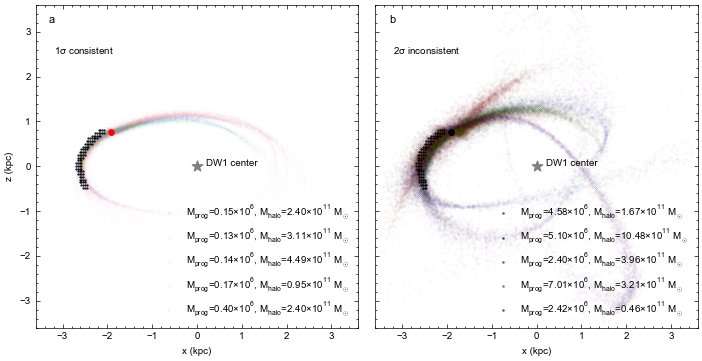

In [60]:
# ── Plot ───────────────────────────────────────────────────────────────────
#f, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
# mpl.rcParams['text.usetex'] = True
# mpl.rcParams['font.family'] = 'Arial'



plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})
f, axes = plt.subplots(1, 2, figsize=(183/25.4, 183/25.4/2), sharex=True, sharey=True)



#figsize=(120/25.4, 7/5*120/25.4)
ax_good, ax_bad = axes


ax_good.set_ylabel('z (kpc)')#, fontsize=16)
#ax_good.set_title('Within 1$\sigma$', fontsize=16)
#ax_bad.set_title('Beyond 2$\sigma$ (≥3 dims)', fontsize=16)

# ── Left panel: good (1-sigma) streams ────────────────────────────────────
for n, stream in enumerate(pale_streams):
    pt = selected_points_1sigma[n]
    m_prog = 10**pt[4] / 1e6        # in units of 10^6 Msun
    m_halo = 10**pt[5] / 1e11       # in units of 10^11 Msun
    label = rf"$M_{{\rm prog}}$={m_prog:.2f}$\times10^6$, $M_{{\rm halo}}$={m_halo:.2f}$\times10^{{11}}$ M$_\odot$"
    ax_good.scatter(
        stream['stream'][:, 0], stream['stream'][:, 2],
        color=pale_colors[n], s=0.0001, alpha=0.6, rasterized=True, label=label
    )
    ax_good.scatter(x_prog, z_prog, marker='.', s=60, color=pale_colors[n], alpha=0.8, zorder=10)

ax_good.scatter(x_prog, z_prog, marker='.', s=60, color='red', zorder=11)
ax_good.legend(loc='lower right', markerscale=30)
ax_good.text(-3.3,3.2,'a', fontsize=8)
ax_bad.text(-3.3,3.2,'b', fontsize=8)#, fontsize=20)
ax_good.text(-3.2,2.5,r'$1\sigma$ consistent')#, fontsize=20)
ax_bad.text(-3.2,2.5,r'$2\sigma$ inconsistent')#, fontsize=20)

# ── Right panel: bad (beyond 2-sigma) streams ─────────────────────────────
for n, stream in enumerate(bad_streams):
    pt = selected_points_2sigma_bad[n]
    m_prog = 10**pt[4] / 1e6
    m_halo = 10**pt[5] / 1e11
    label = rf"$M_{{\rm prog}}$={m_prog:.2f}$\times10^6$, $M_{{\rm halo}}$={m_halo:.2f}$\times10^{{11}}$ M$_\odot$"
    ax_bad.scatter(
        stream['stream'][:, 0], stream['stream'][:, 2],
        color=bad_colors[n], s=0.001, alpha=0.6, rasterized=True, label=label
    )
    ax_bad.scatter(x_prog, z_prog, marker='.', s=60, color=bad_colors[n], alpha=0.8, zorder=10)

ax_bad.scatter(x_prog, z_prog, marker='.', s=60, color='black', zorder=11)
ax_bad.legend(loc='lower right',  markerscale=30)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x (kpc)')#, fontsize=16)
    ax.tick_params(axis='both')#, labelsize=14)
    ax.set_xlim([-3.6, 3.6])
    ax.set_ylim([-3.6, 3.6])
    ax.text(0.2, 0, 'DW1 center', size=7)
    ax.scatter(dat_x[::1], dat_z[::1], color='black', marker='o', s=0.3)
    ax.scatter(0, 0, marker='*', s=60, color='gray', zorder=10)




plt.tight_layout()
#f.savefig('R_good_vs_bad_streams.pdf', dpi=300)
f.savefig('R_good_vs_bad_streams.jpg', dpi=300, bbox_inches='tight', format='jpeg')

## Now make corner plot for extended data figure 

In [61]:
import inspect
from matplotlib import cm  # cm = colormap

print(inspect.signature(plot_corner))

(points_good, prob_values_of_samples, true_params, prior_keys_latex, n_bins=15, show_contours=True, global_norm=False, contour_levels=(0.68, 0.95), smooth_contours=True, smooth_sigma=1.0, contour_on_mean=True, hist1d_on_mean=True, cmap='Purples', contour_colors='k', contour_linestyles=('--', '-'), contour_linewidths=(0.7, 0.6), density=True, hist1d_histtype='bar', hist1d_color='mediumpurple', hist1d_density=True, axis_fraction=1.0, figsize=(22, 22), savefig=None, fig=None, subplot_spec=None, axes_dict=None)


/tmp/ipykernel_494614/1599156519.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  contour_colors=cm.get_cmap('copper')(0.7),
/tmp/ipykernel_494614/1599156519.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hist1d_color=cm.get_cmap('copper')(0.7),
/groups/astro/sapearso/miniforge3/envs/jax_test2/lib/python3.12/site-packages/XStream_utils/plotcontours.py:366: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contour(


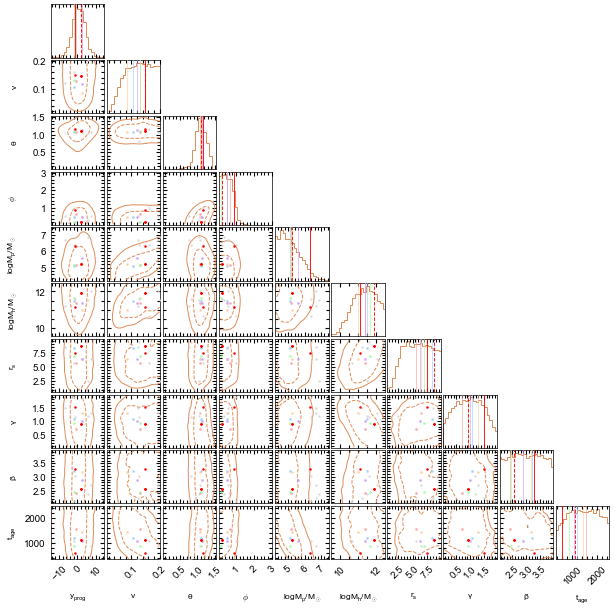

In [62]:
# mpl.rcParams['text.usetex'] = True
# mpl.rcParams['font.family'] = 'Arial'  # or 'Helvetica' which is easier with LaTeX

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

fig, axes = plot_corner(
    pts_c5_all,
    w_c5_all,
    figsize=(183/25.4, 183/25.4), 
    true_params=true_params_all,
    prior_keys_latex=param_labels_all,
    n_bins=20,
    contour_levels=(0.68, 0.95),
    cmap= 'copper',
    #figsize=(22, 22),
    density=False,
    #density_color='copper',
    contour_colors=cm.get_cmap('copper')(0.7),
    contour_linestyles=('-','--'),
    contour_linewidths=(0.7,0.7),
    hist1d_histtype='step',
    hist1d_color=cm.get_cmap('copper')(0.7),
    axis_fraction=.97,
)

# pale_colors = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#CC99FF']

for ax in axes.values():
    ax.tick_params(labelsize=6)  # adjust size as needed




pale_colors = ['#FF9999', '#99CCFF', '#99FF99', '#FFCC99', '#CC99FF']
ndim = len(param_labels_all)

# 1-sigma points — each point gets its own pale color
for n, pt in enumerate(selected_points_1sigma):
    color = pale_colors[n % len(pale_colors)]
    for i in range(ndim):
        for j in range(i):
            ax = axes[(i, j)]
            if np.isnan(pt[j]) or np.isnan(pt[i]):
                continue
            ax.plot(pt[j], pt[i], 'o', color=color, markersize=1, zorder=9, alpha=0.7)
        # Diagonal vertical lines
        ax_diag = axes[(i, i)]
        if not np.isnan(pt[i]):
            ax_diag.axvline(pt[i], color=color, linewidth=0.7, alpha=0.6, zorder=9)

# 2-sigma bad points — all lightgray, no diagonal lines
for n, pt in enumerate(selected_points_2sigma_bad):
    for i in range(ndim):
        for j in range(i):
            ax = axes[(i, j)]
            if np.isnan(pt[j]) or np.isnan(pt[i]):
                continue
            ax.plot(pt[j], pt[i], 'o', color='lightgray', markersize=0.8, zorder=9, alpha=0.7)

# selected_point — red circle, 2D panels
for i in range(ndim):
    for j in range(i):
        ax = axes[(i, j)]
        if not np.isnan(selected_point[j]) and not np.isnan(selected_point[i]):
            ax.plot(selected_point[j], selected_point[i], 'o', color='red', markersize=0.8, zorder=10)

# selected_point_mass — red star, 2D panels
for i in range(ndim):
    for j in range(i):
        ax = axes[(i, j)]
        if not np.isnan(selected_point_mass[j]) and not np.isnan(selected_point_mass[i]):
            ax.plot(selected_point_mass[j], selected_point_mass[i], '*', color='red', markersize=1.5, zorder=10)

# Red vertical lines on diagonal
for i in range(ndim):
    ax_diag = axes[(i, i)]
    if not np.isnan(selected_point[i]):
        ax_diag.axvline(selected_point[i], color='red', linewidth=0.7, alpha=0.9, zorder=10)
    if not np.isnan(selected_point_mass[i]):
        ax_diag.axvline(selected_point_mass[i], color='red', linewidth=0.7, alpha=0.9, zorder=10, linestyle='--')

# Format axes
for (row, col), ax in axes.items():
    # ax.tick_params(axis='both', which='major', length=8)#,# fontsize=7)
    # ax.tick_params(axis='both', which='minor', length=3)#, fontsize=7)
    ax.tick_params(axis='both', which='major', labelsize=7, length=3, width=0.8)
    ax.tick_params(axis='both', which='minor', length=2, width=0.8)
    ax.tick_params(axis='both', colors='k',labelsize=7)
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=6)
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=6)

#fig.savefig("R_full_corner_w17_c5.pdf")
fig.savefig('R_full_corner_w17_c5.jpg', dpi=300, bbox_inches='tight', format='jpeg')

In [63]:
# Now make subset for fig 3

In [64]:
plot_corner

<function XStream_utils.plotcontours.plot_corner(points_good, prob_values_of_samples, true_params, prior_keys_latex, n_bins=15, show_contours=True, global_norm=False, contour_levels=(0.68, 0.95), smooth_contours=True, smooth_sigma=1.0, contour_on_mean=True, hist1d_on_mean=True, cmap='Purples', contour_colors='k', contour_linestyles=('--', '-'), contour_linewidths=(0.7, 0.6), density=True, hist1d_histtype='bar', hist1d_color='mediumpurple', hist1d_density=True, axis_fraction=1.0, figsize=(22, 22), savefig=None, fig=None, subplot_spec=None, axes_dict=None)>

/tmp/ipykernel_494614/2063952568.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  density=False, contour_colors=cm.get_cmap('copper')(0.7),
/tmp/ipykernel_494614/2063952568.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hist1d_color=cm.get_cmap('copper')(0.7), axis_fraction=.97
/groups/astro/sapearso/miniforge3/envs/jax_test2/lib/python3.12/site-packages/XStream_utils/plotcontours.py:366: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contour(
/tmp/ipykernel_494614/2063952568.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use

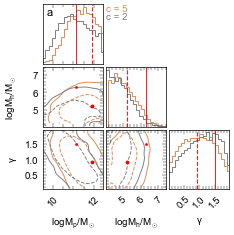

In [65]:


fig, axes = plot_corner(
    pts_c5, w_c5, true_params=true_params, prior_keys_latex=param_labels,
    n_bins=20, contour_levels=(0.68, 0.95), cmap='Purples', figsize=(183/3/25.4, 183/3/25.4),
    density=False, contour_colors=cm.get_cmap('copper')(0.7),
    contour_linestyles=('-','--'), contour_linewidths=(0.7,0.7),hist1d_histtype='step',
    hist1d_color=cm.get_cmap('copper')(0.7), axis_fraction=.97
)
fig, axes = plot_corner(
    pts_c2, w_c2, true_params=true_params, prior_keys_latex=param_labels,
    n_bins=20, contour_levels=(0.68, 0.95), cmap='Purples',figsize=(183/3/25.4, 183/3/25.4),
    density=False, contour_colors='gray', contour_linestyles=('-','--'),contour_linewidths=(0.7,0.7),
    hist1d_histtype='step', hist1d_color='gray', axes_dict=axes, axis_fraction=.97
)

# --- Red dot and star on subset dimensions ---
ndim = len(param_labels)


subset_idx = param_cols  # [5, 4, 7]

for i in range(ndim):
    for j in range(i):
        ax = axes[(i, j)]
        pi, pj = selected_point[subset_idx[i]], selected_point[subset_idx[j]]
        if not np.isnan(pj) and not np.isnan(pi):
            ax.plot(pj, pi, 'o', color='red', markersize=1, zorder=10)
        pi_m, pj_m = selected_point_mass[subset_idx[i]], selected_point_mass[subset_idx[j]]
        if not np.isnan(pj_m) and not np.isnan(pi_m):
            ax.plot(pj_m, pi_m, '*', color='red', markersize=2.5, zorder=10)

for i in range(ndim):
    ax_diag = axes[(i, i)]
    if not np.isnan(selected_point[subset_idx[i]]):
        ax_diag.axvline(selected_point[subset_idx[i]], color='red', linewidth=0.7, alpha=0.9, zorder=10)
    if not np.isnan(selected_point_mass[subset_idx[i]]):
        ax_diag.axvline(selected_point_mass[subset_idx[i]], color='red', linewidth=0.8,
                        alpha=0.9, zorder=10, linestyle='--')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=cm.get_cmap('copper')(0.7), lw=2., label='c = 5'),
    Line2D([0], [0], color='gray', lw=2., label='c = 2'),
]
top_diag = list(axes.values())[0]
top_diag.text(0.05, 0.95, 'a', transform=top_diag.transAxes,
              fontsize=8, ha='left', va='top')
#top_diag.legend(handles=legend_elements, fontsize=12, frameon=False, loc='lower right')

for ax in axes.values():
    ax.tick_params(labelsize=12)  # adjust size as needed
    # ax.set_ylabel(..., color='w')
    # ax.set_xlabel(..., color='w')
    ax.tick_params(axis='both', colors='w',labelsize=12)

top_diag = axes[(0, 0)]  # top diagonal panel

top_diag.text(1.05, 0.92, 'c = 5', transform=top_diag.transAxes,
              fontsize=7, color=cm.get_cmap('copper')(0.7), ha='left', va='center')
top_diag.text(1.05, 0.79, 'c = 2', transform=top_diag.transAxes,
              fontsize=7, color='gray', ha='left', va='center')


from matplotlib.ticker import AutoMinorLocator

for (row, col), ax in axes.items():
    ax.tick_params(axis='both', which='major', labelsize=7, length=3, width=0.3)
    ax.tick_params(axis='both', which='minor', length=2, width=0.3)
    ax.tick_params(axis='both', colors='k',labelsize=7)
    if row != col:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    else:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    # Bigger axis labels
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=7, color='k')
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=7,color='k')

plt.show()
#fig.patch.set_alpha(0)


fig.savefig("R_smallcorner.pdf", dpi=300, bbox_inches='tight')

# Check quantiles

In [66]:
n_bins  = 20
values  = pts_c2_all[:, 4]          # log10(M) column
weights = w_c2_all

# H_mean histogram
H_sum,   edges = np.histogram(values, bins=n_bins, weights=weights)
H_count, _     = np.histogram(values, bins=n_bins)
H_mean = np.where(H_count > 0, H_sum / H_count, 0.0)
centers = 0.5 * (edges[:-1] + edges[1:])

# H_mean quantiles
# q16, q50, q84 = h_mean_quantile(values, weights, [0.16, 0.50, 0.84], n_bins=n_bins)
# print(f'16th pct : {q16:.3f}')
# print(f'median   : {q50:.3f}')
# print(f'84th pct : {q84:.3f}')
# print(f'truth    : {true_params[0]:.3f}')

q025, q16, q50, q84, q975 = h_mean_quantile(values, weights, [0.025, 0.16, 0.50, 0.84, 0.975], n_bins=n_bins)

print(f'2σ lower : {q025:.3f}')
print(f'1σ lower : {q16:.3f}')
print(f'median   : {q50:.3f}')
print(f'1σ upper : {q84:.3f}')
print(f'2σ upper : {q975:.3f}')
print(f'truth    : {true_params[0]:.3f}')

2σ lower : 4.089
1σ lower : 4.147
median   : 4.711
1σ upper : 5.452
2σ upper : 6.184
truth    : 1.000


## Make figure 3 for paperLook at Nib core plot script 

In [67]:
dat_x = np.load('dat_w17_paper.npy')[0]
dat_z = np.load('dat_w17_paper.npy')[1]

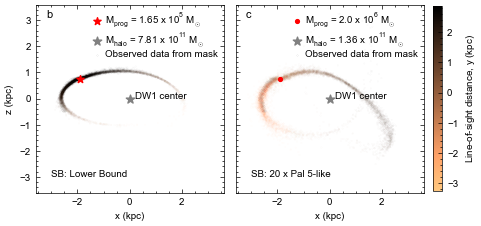

In [70]:

# Create the figure with two subplots side by side
#f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(2/3*183/25.4, 2/3*183/25.4/2), sharex=True, sharey=True,
                              constrained_layout=True,
                              gridspec_kw={'wspace': 0.05})

# ── LEFT PANEL ────────────────────────────────────────────────────────────────
ax1.set_aspect('equal', adjustable='box')

col = UDG_stream_dict_light['stream'][:, 1]
sc1 = ax1.scatter(UDG_stream_dict_light['stream'][:, 0], UDG_stream_dict_light['stream'][:, 2],
                  cmap='copper_r', s=0.0001, c=col, rasterized=True)
ax1.scatter(x_prog, z_prog, marker='*', s=30,
            label=r'M$_{\rm prog}$ = ' + str(np.round(10**log10_M_prog_fit_lowmass / 10**5, 2)) + r' x $10^5$ M$_{\odot}$',
            color='red')
ax1.scatter(0, 0, marker='*', s=40, color='gray',
            label=r'M$_{\rm halo}$ = ' + str(np.round(10**log10_m_halo_fit_lowmass / 1e11, 2)) + r' x $10^{11}$ M$_{\odot}$')
ax1.scatter(dat_x[::1], dat_z[::1], color='black', s=0.001, label='Observed data from mask')
ax1.text(-3, -3., 'SB: Lower Bound', fontsize=7)
ax1.set_xlabel('x (kpc)', fontsize=7, color='k')
ax1.set_ylabel('z (kpc)', fontsize=7, color='k')
ax1.tick_params(axis='both', labelsize=7, colors='k')
ax1.set_xlim([-3.6, 3.6])
ax1.set_ylim([-3.6, 3.6])
ax1.legend(loc='upper right', fontsize=7)
ax1.text(0.2, 0, 'DW1 center', size=7)

# ── RIGHT PANEL ───────────────────────────────────────────────────────────────
ax2.set_aspect('equal', adjustable='box')

col2 = UDG_stream_dict1['stream'][:, 1]
sc2 = ax2.scatter(UDG_stream_dict1['stream'][:, 0], UDG_stream_dict1['stream'][:, 2],
                  cmap='copper_r', s=0.0001, c=col2, rasterized=True)
ax2.scatter(x_prog, z_prog, marker='.', s=30,
            label=r'M$_{\rm prog}$ = ' + str(np.round(10**log10_M_prog_fit / 10**6, 2)) + r' x $10^6$ M$_{\odot}$',
            color='red')
ax2.scatter(0, 0, marker='*', s=40, color='gray',
            label=r'M$_{\rm halo}$ = ' + str(np.round(10**log10_m_halo_fit / 1e11, 2)) + r' x $10^{11}$ M$_{\odot}$')
ax2.scatter(dat_x[::1], dat_z[::1], color='black', marker='o', s=0.001, label='Observed data from mask')
ax2.text(-3, -3., 'SB: 20 x Pal 5-like', fontsize=7)
ax2.set_xlabel('x (kpc)', fontsize=7, color='k')
# No y-axis label on right panel
ax2.tick_params(axis='both', labelsize=7, colors='k')
ax2.set_xlim([-3.6, 3.6])
ax2.set_ylim([-3.6, 3.6])
ax2.legend(loc='upper right', fontsize=7)
ax2.text(0.2, 0, 'DW1 center', size=7)

ax1.text(-3.2,3.1,'b', fontsize=8)
ax2.text(-3.2,3.1,'c', fontsize=8)#, fontsize=20)

legend_kw = dict(loc='upper right', fontsize=7, handlelength=0.8, handletextpad=0.4, labelspacing=0.05, borderpad=0.1)
ax1.legend(**legend_kw)
ax2.legend(**legend_kw)

# ── SINGLE COLORBAR (right panel only) ───────────────────────────────────────
#cbar = plt.colorbar(sc2, ax=ax2)
cbar = plt.colorbar(sc2, ax=ax2, shrink=0.88)
cbar.set_label('Line-of-sight distance, $y$ (kpc)', fontsize=7, color='k')

cbar.ax.tick_params(labelsize=7)

#plt.tight_layout()
plt.show()
f.savefig("R_2streams.pdf", dpi=300, bbox_inches='tight')

# Below is the wide dwarf stream for the mock obs figure

pos = [-1.91 -1.45  0.76] kpc
vel = [ 82.81 104.57  57.36] km/s
M$_{\rm halo,tot}$ = 1.36x $10^{11}$M$_{\odot}$


<>:16: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_494614/3142977828.py:16: SyntaxWarning: invalid escape sequence '\o'
  ax.scatter(x_prog, z_prog, marker='.', s=100, label=r'M$_{\rm prog}$ = ' + str(np.round(10**7.3/10**6,2)) + ' x $10^6$ M$_{\odot}$', color='red')


Text(0.2, 0, 'DW1 center')

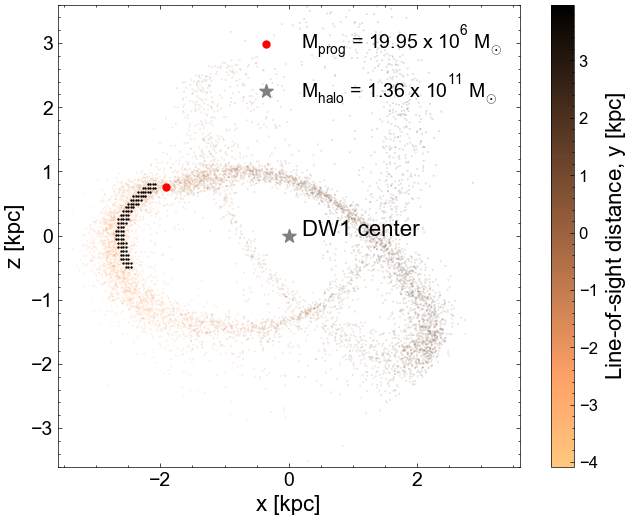

In [69]:
import matplotlib.pyplot as plt

# Create the figure and axis
f, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True, sharey=True)
#ax.set_title('Best fit', fontsize=18)  # Larger title
ax.set_aspect('equal', adjustable='box')
# Scatter plot of stream
col = UDG_stream_dict_massive['stream'][:,1]

          # label='vel = ' + str(np.round(velocity_today_fit * (u.kpc/u.Myr).to(u.km/u.s), 2)) + ' km/s')



sc = ax.scatter(UDG_stream_dict_massive['stream'][:, 0], UDG_stream_dict_massive['stream'][:, 2], cmap='copper_r',
                s=0.006, c=col, rasterized=True)#, label='pos = ' + str(np.round(pos_today_fit, 2)) + ' kpc')
ax.scatter(x_prog, z_prog, marker='.', s=100, label=r'M$_{\rm prog}$ = ' + str(np.round(10**7.3/10**6,2)) + ' x $10^6$ M$_{\odot}$', color='red')
ax.scatter(0,0, marker='*', s=100, color='gray', label=r'M$_{ \rm halo}$ = ' + str(np.round(10**log10_m_halo_fit/ 1e11, 2)) + r' x $10^{11}$ M$_{\odot}$')
           #label=r'M$_{ \rm halo,enclosed}$ = ' + str(np.round(M_halo_enc_jax[0] / 1e9, 2)) + r' x $10^9$ M$_{\odot}$')

ax.scatter(dat_x[::1], dat_z[::1], color='black', s=0.5)#,# cmap='Blues',
print('pos = ' + str(np.round(pos_today_fit, 2)) + ' kpc')
print('vel = ' + str(np.round(velocity_today_fit * (u.kpc/u.Myr).to(u.km/u.s), 2)) + ' km/s')
print(r'M$_{\rm halo,tot}$ = ' + str(np.round(10**log10_m_halo_fit / 1e11, 2)) + r'x $10^{11}$M$_{\odot}$')

# Axis labels with larger font
ax.set_xlabel('x [kpc]', fontsize=16)
ax.set_ylabel('z [kpc]', fontsize=16)

# Set tick label sizes
ax.tick_params(axis='both', labelsize=14)

# Limits
ax.set_xlim([-3.6, 3.6])
ax.set_ylim([-3.6, 3.6])

# Legend
ax.legend(loc='upper right', fontsize=14)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Line-of-sight distance, $y$ [kpc]', fontsize=16)
cbar.ax.tick_params(labelsize=12)

# Annotate with text
ax.text(0.2, 0, 'DW1 center', size=16)
